In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
x=np.linspace(-6,6,1000)
y=np.sqrt(10**2-x**2)
y=np.hstack([y,-y])
x=np.hstack([x,-x])

In [10]:
x1 = np.linspace(-6.0, 6.0, 1000)
y1 = np.sqrt(4**2 - x1**2)
y1=np.hstack([y1,-y1])
x1=np.hstack([x1,-x1])

C:\Users\Mcc\AppData\Local\Temp\ipykernel_6600\4196262048.py:2: RuntimeWarning: invalid value encountered in sqrt
  y1 = np.sqrt(4**2 - x1**2)


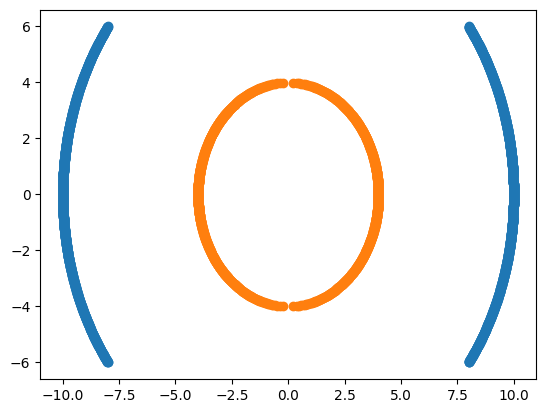

In [11]:
plt.scatter(y,x)
plt.scatter(y1,x1)

In [12]:
df1 = pd.DataFrame(np.vstack([y, x]).T, columns=['X1', 'X2'])
df1['Y'] = 0
df2 = pd.DataFrame(np.vstack([y1, x1]).T, columns=['X1', 'X2'])
df2['Y'] = 1
df = pd.concat([df1, df2], ignore_index=True)
df.head(5)

,X1,X2,Y
0,8.000000,-6.000000,0
1,8.008995,-5.987988,0
2,8.017962,-5.975976,0
3,8.026901,-5.963964,0
4,8.035812,-5.951952,0


In [13]:
print(x.shape)
print(y.shape)
print(x1.shape)
print(y1.shape)

(2000,)
(2000,)
(2000,)
(2000,)


In [14]:
df1 = df.copy()

In [15]:
df1 = df1.dropna()

In [16]:
df1["x1square"] = df1["X1"]**2
df1["x2square"] = df1["X2"]**2
df1["x1x2"] = df1["X1"]*df1["X2"]
df1.head()

,X1,X2,Y,x1square,x2square,x1x2
0,8.000000,-6.000000,0,64.000000,36.000000,-48.000000
1,8.008995,-5.987988,0,64.144000,35.856000,-47.957765
2,8.017962,-5.975976,0,64.287711,35.712289,-47.915147
3,8.026901,-5.963964,0,64.431134,35.568866,-47.872146
4,8.035812,-5.951952,0,64.574268,35.425732,-47.828764


In [17]:
X = df1[["x1square", "x2square", "x1x2"]]
y = df1['Y']

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

In [19]:
!pip install plotly

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.9 MB 5.6 MB/s eta 0:00:02
   ----------- ---------------------------- 2.9/9.9 MB 5.8 MB/s eta 0:00:02
   ----------------- ---------------------- 4.5/9.9 MB 6.4 MB/s eta 0:00:01
   ------------------------ --------------- 6.0/9.9 MB 6.7 MB/s eta 0:00:01
   ------------------------------- -------- 7.9/9.9 MB 7.2 MB/s eta 0:00:01
   -------------------------------------- - 9.4/9.9 MB 7.2 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 6.9 MB/s  0:00:01

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------

In [20]:
import plotly.express as px

In [21]:
fig = px.scatter_3d(df1, x= "x1square", y = "x2square", z = "x1x2", color = "Y")
fig.show()


In [22]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
cls = SVC(kernel = 'linear') #why linear>> we have created polynomial
cls.fit(X_train, y_train)
y_pred = cls.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [23]:

df = df.dropna()

In [24]:
X = df[["X1", "X2"]]
y = df["Y"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

In [25]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
cls = SVC(kernel = 'poly') #why linear>> we have created polynomial
cls.fit(X_train, y_train)
y_pred = cls.predict(X_test)
accuracy_score(y_test, y_pred)

0.629

In [26]:
#Ploy kernel didnt perform well, so we used rbf
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
cls = SVC(kernel = 'rbf') #why linear>> we have created polynomial
cls.fit(X_train, y_train)
y_pred = cls.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [27]:
#sigmoid kernel
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
cls = SVC(kernel = 'sigmoid') #why linear>> we have created polynomial
cls.fit(X_train, y_train)
y_pred = cls.predict(X_test)
accuracy_score(y_test, y_pred)

0.546